In [1]:
%pip install -e .[dev]

Note: you may need to restart the kernel to use updated packages.


C:\Users\Alexander\PycharmProjects\ECup\.venv\Scripts\python.exe: No module named pip


# ECup EDA



In [2]:
%matplotlib inline

import json
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import utility
from sklearn.metrics import average_precision_score

In [3]:
env = utility.load()

In [4]:
repo_url = f"hf://datasets/{env.config.data.data_repo}"

items = pl.scan_parquet(f"{repo_url}/{env.config.data.items}")
items_human = pl.scan_parquet(f"{repo_url}/{env.config.data.items_human}")
matches = pl.scan_parquet(f"{repo_url}/{env.config.data.matches}")
matches_llm = pl.scan_parquet(f"{repo_url}/{env.config.data.matches_llm}")

In [5]:
for name, frame in [("items", items), ("items_human", items_human), ("matches", matches), ("matches_llm", matches_llm)]:
    print(name)
    print(frame.collect_schema())

items
Schema({'id': Int64, 'name': String, 'attributes': String, 'category': String})
items_human
Schema({'id': Int64, 'name': String, 'attributes': String, 'category': String})
matches
Schema({'id1': Int64, 'id2': Int64, 'target': Float64})
matches_llm
Schema({'id1': Int64, 'id2': Int64, 'target': Float64})


In [6]:
for name, frame in [("items", items), ("items_human", items_human), ("matches", matches), ("matches_llm", matches_llm)]:
    print(name, frame.select(pl.len()).collect().item())

items 13397761
items_human 711304
matches 365654
matches_llm 11187780


## 1. Как выглядят данные


In [7]:
print("items:")
print(items.head(5).collect())
print("items_human:")
print(items_human.head(5).collect())

items:
shape: (5, 4)
┌─────┬─────────────────────────────────┬─────────────────────────────────┬────────────┐
│ id  ┆ name                            ┆ attributes                      ┆ category   │
│ --- ┆ ---                             ┆ ---                             ┆ ---        │
│ i64 ┆ str                             ┆ str                             ┆ str        │
╞═════╪═════════════════════════════════╪═════════════════════════════════╪════════════╡
│ 9   ┆ суппорт тормозной задний левый… ┆ {"бренд":"masterkit","цвет тов… ┆ Автотовары │
│ 25  ┆ sufix / тяга продольная верхня… ┆ {"артикул производителя":"si11… ┆ Автотовары │
│ 51  ┆ haft шрус наружный, арт. ga016… ┆ {"бренд":"haft","oem-номер":"4… ┆ Автотовары │
│ 62  ┆ наконечник рулевой левый peuge… ┆ {"бренд":"stellox","количество… ┆ Автотовары │
│ 74  ┆ carberry / 6pk905, ремень поли… ┆ {"артикул производителя":"6pk9… ┆ Автотовары │
└─────┴─────────────────────────────────┴─────────────────────────────────┴────────────┘


In [8]:
pair_view = (
    matches.rename({"target": "target_human"})
    .join(items_human.select("id", "name", "category"), left_on="id1", right_on="id")
    .rename({"name": "name1", "category": "cat1"})
    .join(items_human.select("id", "name", "category"), left_on="id2", right_on="id")
    .rename({"name": "name2", "category": "cat2"})
    .select("target_human", "cat1", "cat2", "name1", "name2")
    .collect()
)

print("positive pairs:")
print(pair_view.filter(pl.col("target_human") == 1).head(3))
print("negative pairs:")
print(pair_view.filter(pl.col("target_human") == 0).head(3))

positive pairs:
shape: (3, 5)
┌──────────────┬────────────┬────────────┬────────────────────────────┬────────────────────────────┐
│ target_human ┆ cat1       ┆ cat2       ┆ name1                      ┆ name2                      │
│ ---          ┆ ---        ┆ ---        ┆ ---                        ┆ ---                        │
│ f64          ┆ str        ┆ str        ┆ str                        ┆ str                        │
╞══════════════╪════════════╪════════════╪════════════════════════════╪════════════════════════════╡
│ 1.0          ┆ Автотовары ┆ Автотовары ┆ avtolider1 оплетка на      ┆ / оплетка на руль для лада │
│              ┆            ┆            ┆ руль, ди…                  ┆ lar…                       │
│ 1.0          ┆ Автотовары ┆ Автотовары ┆ galia оцинкованный фаркоп  ┆ фаркоп оцинкованный galia  │
│              ┆            ┆            ┆ на c…                      ┆ t077…                      │
│ 1.0          ┆ Автотовары ┆ Автотовары ┆ натяжитель приводн

## 2. Категории: items_human vs items


In [9]:
category_counts = items_human.group_by("category").len().sort("len", descending=True).collect()
print("categories in items_human:", category_counts.height)
category_counts

categories in items_human: 20


category,len
str,u32
"""Одежда""",45878
"""Автотовары""",37752
"""Строительство и ремонт""",36088
"""Обувь""",35936
"""Товары для животных""",35663
…,…
"""Электроника""",34455
"""Канцелярские товары""",34436
"""Красота и гигиена""",34299


categories in items: 20 vs items_human: 20


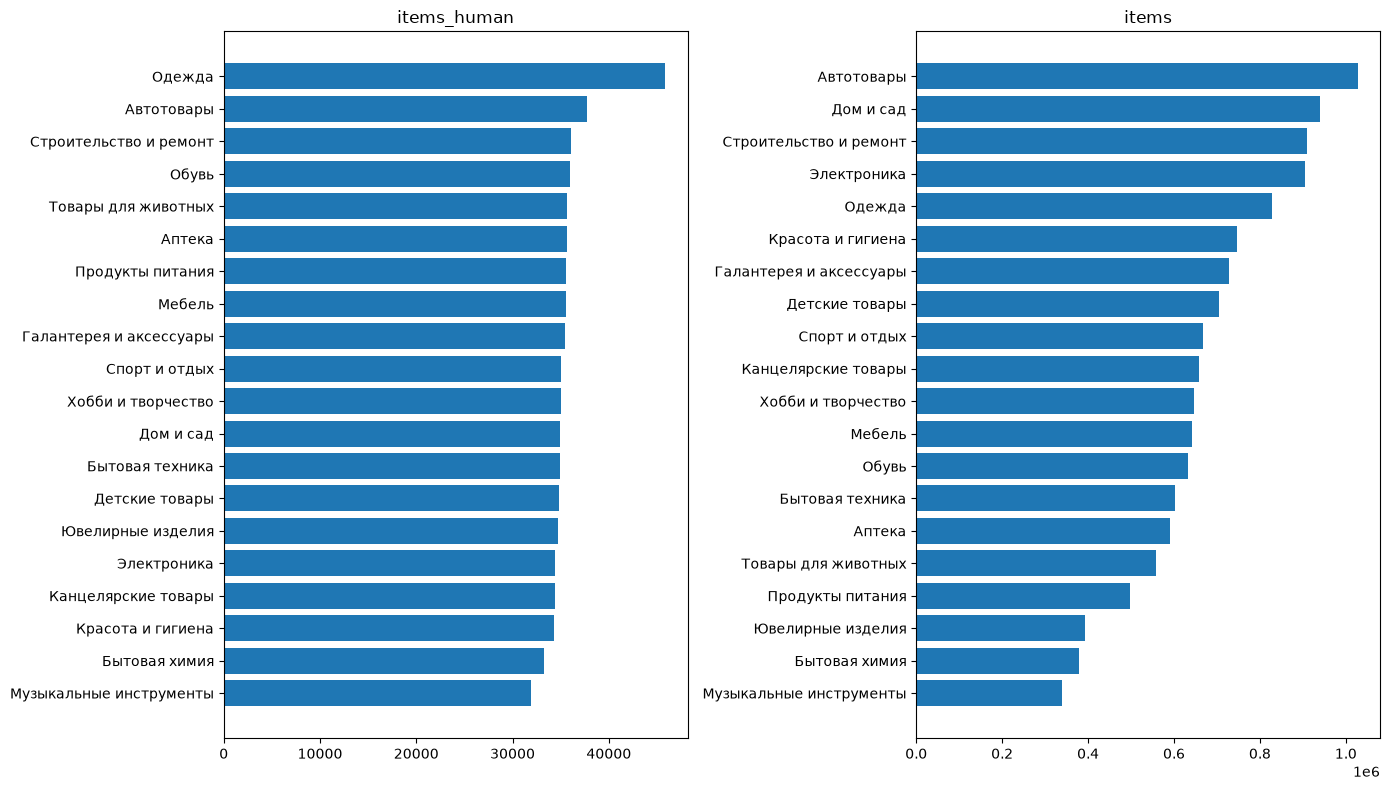

category,len,share
str,u32,f64
"""Автотовары""",1028081,0.0767
"""Дом и сад""",938725,0.0701
"""Строительство и ремонт""",909895,0.0679
"""Электроника""",905213,0.0676
"""Одежда""",827617,0.0618
…,…,…
"""Товары для животных""",558992,0.0417
"""Продукты питания""",497606,0.0371
"""Ювелирные изделия""",392755,0.0293


In [10]:
items_cat_counts = items.group_by("category").len().sort("len", descending=True).collect()
print("categories in items:", items_cat_counts.height, "vs items_human:", category_counts.height)

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
for ax, frame, title in [
    (axes[0], category_counts, "items_human"),
    (axes[1], items_cat_counts, "items"),
]:
    ax.barh(frame["category"].to_list(), frame["len"].to_numpy())
    ax.invert_yaxis()
    ax.set_title(title)
plt.tight_layout()
plt.show()

items_cat_counts = items_cat_counts.with_columns(
    (pl.col("len") / items_cat_counts["len"].sum()).round(4).alias("share")
)
items_cat_counts

## 3. Качество карточек

Оба файла одинаковой схемы. Для items_human мы уже знаем: идеальная чистота. Повторяем то же для items.


In [11]:
name_stats = items_human.select(
    pl.col("name").is_null().sum().alias("null_names"),
    pl.col("name").str.len_chars().eq(0).sum().alias("empty_names"),
    pl.col("name").str.len_chars().mean().round(1).alias("mean_name_len"),
    pl.col("name").str.len_chars().median().alias("median_name_len"),
).collect()
print("items_human:")
print(name_stats)

items_human.select("name", "attributes", "category").head(5).collect()

items_human:
shape: (1, 4)
┌────────────┬─────────────┬───────────────┬─────────────────┐
│ null_names ┆ empty_names ┆ mean_name_len ┆ median_name_len │
│ ---        ┆ ---         ┆ ---           ┆ ---             │
│ u32        ┆ u32         ┆ f64           ┆ f64             │
╞════════════╪═════════════╪═══════════════╪═════════════════╡
│ 0          ┆ 0           ┆ 57.7          ┆ 54.0            │
└────────────┴─────────────┴───────────────┴─────────────────┘


name,attributes,category
str,str,str
"""victor reinz прокладка впускно…","""{""артикул"":""703315700"",""бренд""…","""Автотовары"""
"""stellox диск тормозной, арт. 8…","""{""артикул"":""stellox_8500892sx""…","""Автотовары"""
"""комплект подшипника ступицы ко…","""{""артикул производителя"":"""",""б…","""Автотовары"""
"""kraft подшипник ступицы, арт. …","""{""артикул"":""112097-01"",""бренд""…","""Автотовары"""
"""фильтр салонный skoda fabia 00…","""{""альтернативные артикулы това…","""Автотовары"""


In [12]:
attr_stats = items_human.select(
    pl.col("attributes").is_null().sum().alias("null_attrs"),
    pl.col("attributes").str.len_chars().eq(0).sum().alias("empty_attrs"),
).collect()
print("items_human:")
print(attr_stats)

malformed = (
    items_human.filter(pl.col("attributes").is_not_null())
    .filter(~(pl.col("attributes").str.starts_with("{") & pl.col("attributes").str.ends_with("}")))
    .collect()
    .height
)
print("malformed json (starts/ends heuristic):", malformed)

items_human:
shape: (1, 2)
┌────────────┬─────────────┐
│ null_attrs ┆ empty_attrs │
│ ---        ┆ ---         │
│ u32        ┆ u32         │
╞════════════╪═════════════╡
│ 0          ┆ 0           │
└────────────┴─────────────┘
malformed json (starts/ends heuristic): 0


In [13]:
items_quality = items.select(
    pl.col("name").is_null().sum().alias("null_names"),
    pl.col("name").str.len_chars().eq(0).sum().alias("empty_names"),
    pl.col("attributes").is_null().sum().alias("null_attrs"),
    pl.col("attributes").str.len_chars().eq(0).sum().alias("empty_attrs"),
    pl.col("category").is_null().sum().alias("null_category"),
    pl.col("category").n_unique().alias("n_categories"),
).collect()
print(items_quality)

items_malformed = (
    items.filter(~(pl.col("attributes").str.starts_with("{") & pl.col("attributes").str.ends_with("}")))
    .select(pl.len())
    .collect()
    .item()
)
print("malformed json (starts/ends heuristic):", items_malformed)

items_duplicate_ids = items.group_by("id").len().filter(pl.col("len") > 1).select(pl.len()).collect().item()
print("duplicate ids:", items_duplicate_ids)

items_unique_names = items.select(pl.col("name").n_unique()).collect().item()
print("unique names:", items_unique_names)

shape: (1, 6)
┌────────────┬─────────────┬────────────┬─────────────┬───────────────┬──────────────┐
│ null_names ┆ empty_names ┆ null_attrs ┆ empty_attrs ┆ null_category ┆ n_categories │
│ ---        ┆ ---         ┆ ---        ┆ ---         ┆ ---           ┆ ---          │
│ u32        ┆ u32         ┆ u32        ┆ u32         ┆ u32           ┆ u32          │
╞════════════╪═════════════╪════════════╪═════════════╪═══════════════╪══════════════╡
│ 0          ┆ 11          ┆ 0          ┆ 0           ┆ 0             ┆ 20           │
└────────────┴─────────────┴────────────┴─────────────┴───────────────┴──────────────┘
malformed json (starts/ends heuristic): 0
duplicate ids: 0
unique names: 8761656


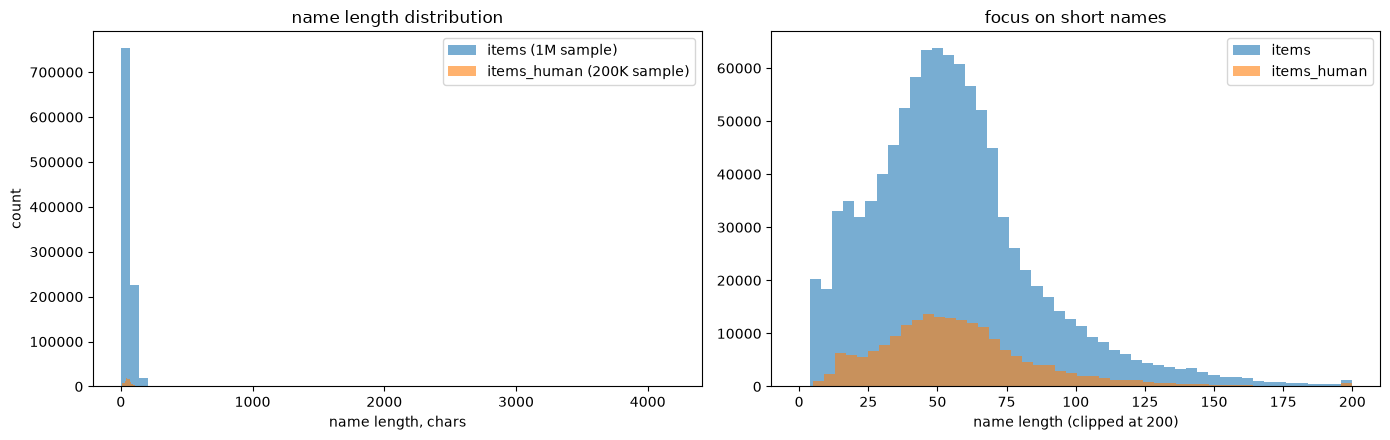

items: mean 55.3, median 52.0
items_human: mean 57.6, median 54.0


In [14]:
items_name_len = items.select(pl.col("name").str.len_chars().alias("len")).collect().sample(n=1_000_000, seed=0).to_series().to_numpy()
human_name_len = items_human.select(pl.col("name").str.len_chars().alias("len")).collect().sample(n=200_000, seed=0).to_series().to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].hist(items_name_len, bins=60, alpha=0.6, label="items (1M sample)")
axes[0].hist(human_name_len, bins=60, alpha=0.6, label="items_human (200K sample)")
axes[0].set_xlabel("name length, chars")
axes[0].set_ylabel("count")
axes[0].legend()
axes[0].set_title("name length distribution")

axes[1].hist(np.clip(items_name_len, 0, 200), bins=50, alpha=0.6, label="items")
axes[1].hist(np.clip(human_name_len, 0, 200), bins=50, alpha=0.6, label="items_human")
axes[1].set_xlabel("name length (clipped at 200)")
axes[1].legend()
axes[1].set_title("focus on short names")
plt.tight_layout()
plt.show()

print(f"items: mean {items_name_len.mean():.1f}, median {np.median(items_name_len):.1f}")
print(f"items_human: mean {human_name_len.mean():.1f}, median {np.median(human_name_len):.1f}")

In [15]:
empty_name_items = items.filter(pl.col("name").is_null().or_(pl.col("name").str.len_chars().eq(0)))
empty_name_n = empty_name_items.select(pl.len()).collect().item()
if empty_name_n:
    empty_name_items.group_by("category").len().sort("len", descending=True).collect()
else:
    print("no items with empty name")

empty_attrs_items = items.filter(pl.col("attributes").is_null().or_(pl.col("attributes").str.len_chars().eq(0)))
empty_attrs_n = empty_attrs_items.select(pl.len()).collect().item()
if empty_attrs_n:
    empty_attrs_items.group_by("category").len().sort("len", descending=True).collect()
else:
    print("no items with empty attributes")

no items with empty attributes


## 4. Пары: matches (human) vs matches_llm


In [16]:
match_stats = matches.select(
    pl.len().alias("n_pairs"),
    pl.col("target").mean().round(4).alias("positive_rate"),
).collect()
print(match_stats)

shape: (1, 2)
┌─────────┬───────────────┐
│ n_pairs ┆ positive_rate │
│ ---     ┆ ---           │
│ u32     ┆ f64           │
╞═════════╪═══════════════╡
│ 365654  ┆ 0.2568        │
└─────────┴───────────────┘


In [17]:
item_categories = items_human.select("id", "category").collect()

pair_categories = (
    matches.join(item_categories.lazy(), left_on="id1", right_on="id")
    .rename({"category": "cat1"})
    .join(item_categories.lazy(), left_on="id2", right_on="id")
    .rename({"category": "cat2"})
    .collect()
)

print("pairs with both items found:", pair_categories.height)
print("cross-category pairs:", pair_categories.filter(pl.col("cat1") != pl.col("cat2")).height)

pair_categories.group_by("cat1").len().sort("len", descending=True)

pairs with both items found: 365654
cross-category pairs: 0


cat1,len
str,u32
"""Одежда""",23357
"""Автотовары""",19010
"""Ювелирные изделия""",18695
"""Электроника""",18681
"""Мебель""",18366
…,…
"""Дом и сад""",17574
"""Детские товары""",17561
"""Бытовая химия""",17436


In [18]:
unique_pairs = matches.group_by("id1", "id2").len().collect()
print("unique (id1, id2) pairs:", unique_pairs.height)

self_pairs = matches.filter(pl.col("id1") == pl.col("id2")).collect().height
print("self pairs (id1 == id2):", self_pairs)

print("top hub items by pair count:")
matches.group_by("id1").len().sort("len", descending=True).head(10).collect()

unique (id1, id2) pairs: 365654
self pairs (id1 == id2): 0
top hub items by pair count:


id1,len
i64,u32
687194912024,13
798863974510,12
257698100757,11
8590100107,11
77309546381,11
163208775658,11
231928367348,10
139347,10
661425078188,10


In [19]:
known_ids = item_categories.select("id")

missing_id1 = matches.join(known_ids.lazy(), left_on="id1", right_on="id", how="anti").select(pl.col("id1").n_unique()).collect().item()
missing_id2 = matches.join(known_ids.lazy(), left_on="id2", right_on="id", how="anti").select(pl.col("id2").n_unique()).collect().item()

print("unique id1 missing from items_human:", missing_id1)
print("unique id2 missing from items_human:", missing_id2)

print("unique ids in items_human:", known_ids.height)

unique id1 missing from items_human: 0
unique id2 missing from items_human: 0
unique ids in items_human: 711304


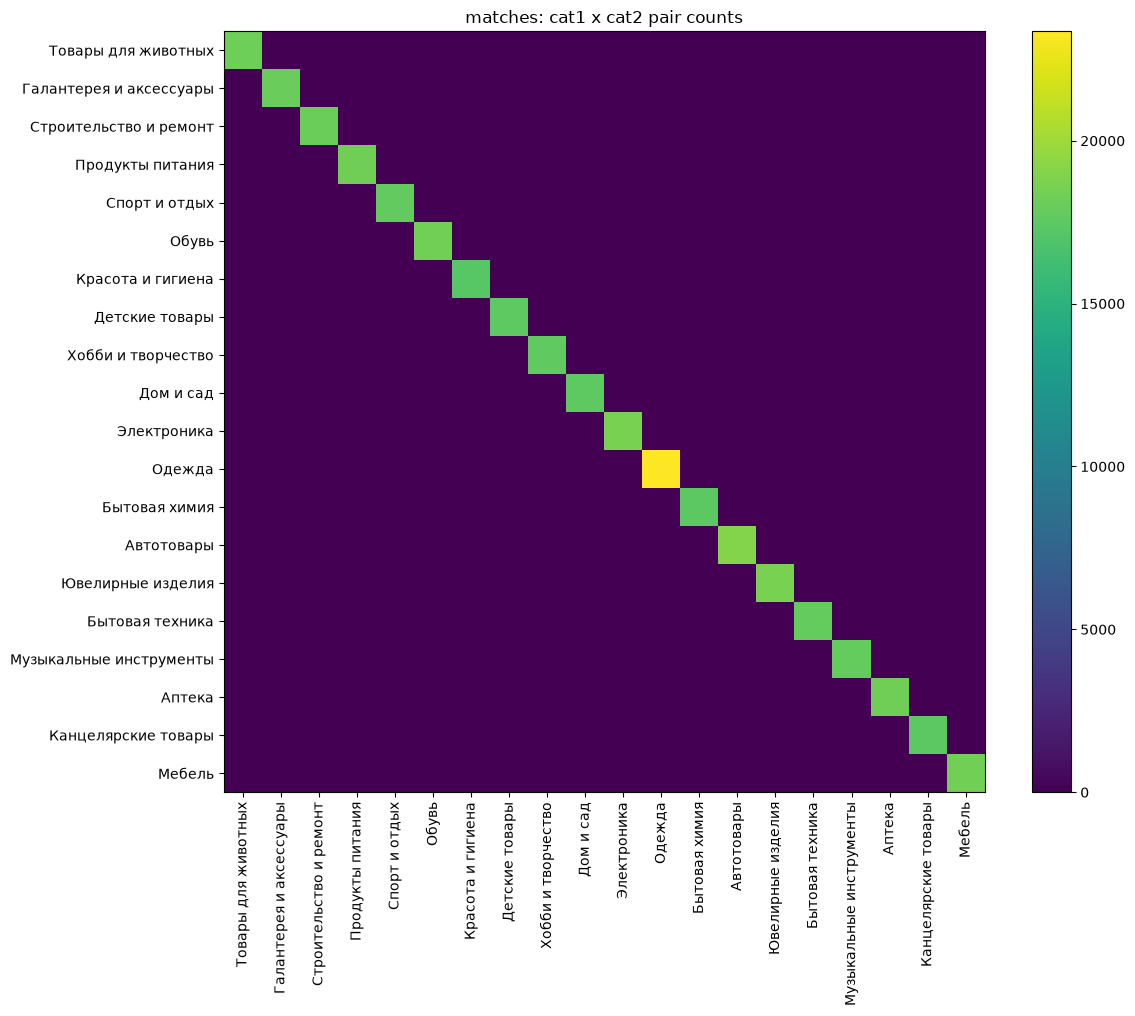

In [20]:
pair_matrix = pair_categories.group_by("cat1", "cat2").len().pivot(on="cat2", index="cat1", values="len").fill_null(0)
cats = pair_matrix["cat1"].to_list()
matrix = pair_matrix.select(pl.exclude("cat1")).to_numpy()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(matrix, cmap="viridis")
ax.set_xticks(range(len(cats)), cats, rotation=90)
ax.set_yticks(range(len(cats)), cats)
ax.set_title("matches: cat1 x cat2 pair counts")
plt.colorbar(im)
plt.tight_layout()
plt.show()

In [21]:
llm_stats = matches_llm.select(
    pl.len().alias("n_pairs"),
    pl.col("target").mean().round(4).alias("mean_target"),
    pl.col("target").median().alias("median_target"),
).collect()
print(llm_stats)

llm_bins = (
    matches_llm.with_columns(
        pl.when(pl.col("target") == 0.0).then(pl.lit(0))
        .when(pl.col("target") < 0.5).then(pl.lit(1))
        .when(pl.col("target") < 1.0).then(pl.lit(2))
        .otherwise(pl.lit(3))
        .alias("bin")
    )
    .group_by("bin")
    .len()
    .sort("bin")
    .collect()
)
llm_bins = llm_bins.with_columns((pl.col("len") / llm_bins["len"].sum() * 100).round(2).alias("pct"))
print("bins: 0=exact 0, 1=(0,0.5), 2=[0.5,1), 3=exact 1")
llm_bins

shape: (1, 3)
┌──────────┬─────────────┬───────────────┐
│ n_pairs  ┆ mean_target ┆ median_target │
│ ---      ┆ ---         ┆ ---           │
│ u32      ┆ f64         ┆ f64           │
╞══════════╪═════════════╪═══════════════╡
│ 11187780 ┆ 0.2436      ┆ 0.0           │
└──────────┴─────────────┴───────────────┘
bins: 0=exact 0, 1=(0,0.5), 2=[0.5,1), 3=exact 1


bin,len,pct
i32,u32,f64
0,7184663,64.22
1,1383550,12.37
2,1395612,12.47
3,1223955,10.94


duplicate pairs in matches_llm: 0
self pairs in matches_llm: 0
shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ value      │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 7.291795e6 │
│ null_count ┆ 0.0        │
│ mean       ┆ 1.534297   │
│ std        ┆ 2.018364   │
│ min        ┆ 1.0        │
│ 25%        ┆ 1.0        │
│ 50%        ┆ 1.0        │
│ 75%        ┆ 1.0        │
│ max        ┆ 122.0      │
└────────────┴────────────┘


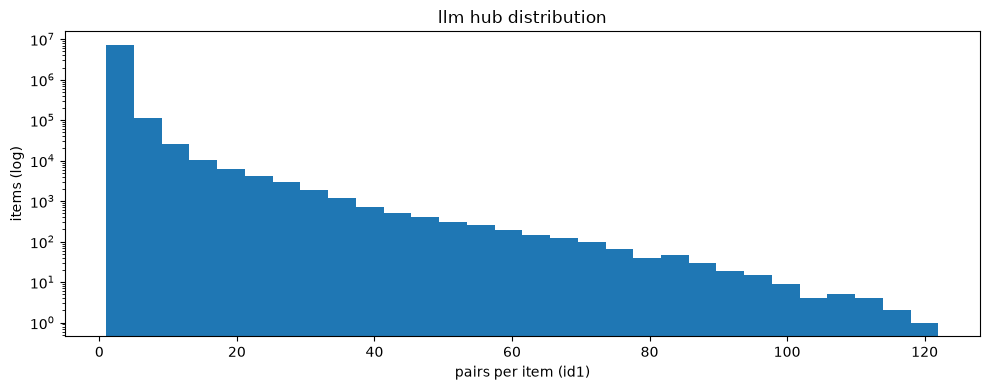

In [22]:
llm_duplicate_pairs = matches_llm.group_by("id1", "id2").len().filter(pl.col("len") > 1).select(pl.len()).collect().item()
llm_self_pairs = matches_llm.filter(pl.col("id1") == pl.col("id2")).select(pl.len()).collect().item()
print("duplicate pairs in matches_llm:", llm_duplicate_pairs)
print("self pairs in matches_llm:", llm_self_pairs)

llm_hubs = matches_llm.group_by("id1").len().collect()
print(llm_hubs["len"].describe())

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(llm_hubs["len"].to_numpy(), bins=30, log=True)
ax.set_xlabel("pairs per item (id1)")
ax.set_ylabel("items (log)")
ax.set_title("llm hub distribution")
plt.tight_layout()
plt.show()

In [23]:
llm_distribution = (
    matches_llm.select((pl.col("target") * 10).cast(pl.Int32).alias("bucket"))
    .group_by("bucket")
    .len()
    .sort("bucket")
    .collect()
)
llm_distribution

bucket,len
i32,u32
0,7184663
1,1434
2,632415
3,497157
4,252544
5,269160
6,170222
7,276349
8,679881


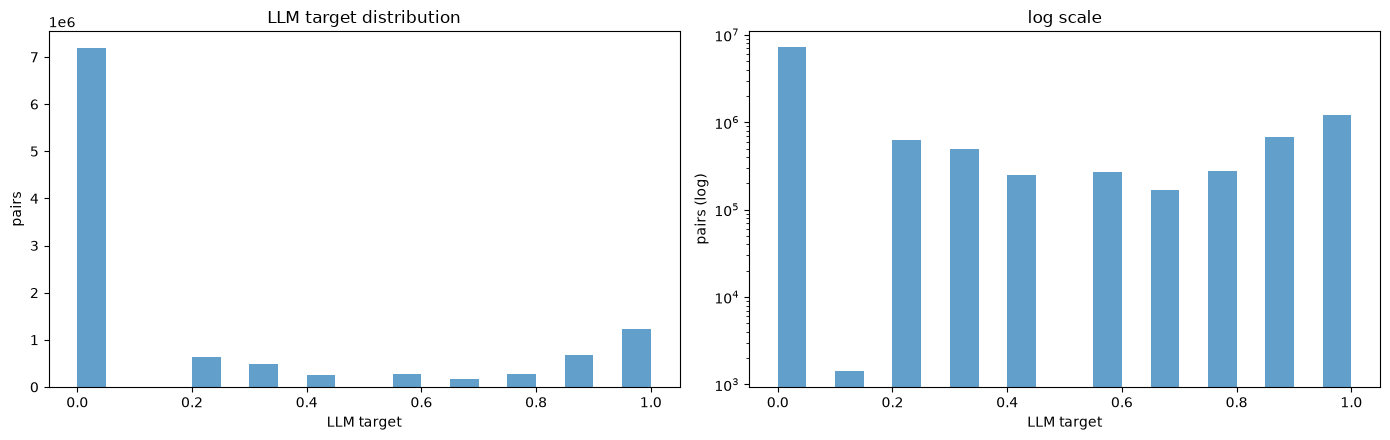

exact 0: 0.6422, exact 1: 0.1094, share < 0.5: 0.7659


In [24]:
targets = matches_llm.select("target").collect().to_series().to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].hist(targets, bins=20, alpha=0.7)
axes[0].set_xlabel("LLM target")
axes[0].set_ylabel("pairs")
axes[0].set_title("LLM target distribution")

axes[1].hist(targets, bins=20, log=True, alpha=0.7)
axes[1].set_xlabel("LLM target")
axes[1].set_ylabel("pairs (log)")
axes[1].set_title("log scale")
plt.tight_layout()
plt.show()

print(f"exact 0: {np.mean(targets == 0.0):.4f}, exact 1: {np.mean(targets == 1.0):.4f}, share < 0.5: {np.mean(targets < 0.5):.4f}")

## 5. Пересечение matches и matches_llm


In [25]:
overlap = (
    matches.rename({"target": "target_human"})
    .join(matches_llm.rename({"target": "target_llm"}), on=["id1", "id2"], how="inner")
    .collect()
)
print("human-llm overlapping pairs:", overlap.height)

if overlap.height:
    corr = overlap.select(pl.corr(pl.col("target_human"), pl.col("target_llm"))).item()
    ap = average_precision_score(overlap["target_human"].to_numpy(), overlap["target_llm"].to_numpy())
    print(f"correlation: {corr:.4f}, LLM AP vs human: {ap:.4f}")
    overlap.group_by("target_human").agg(
        pl.col("target_llm").mean().round(4).alias("mean_llm"),
        pl.len().alias("n_pairs"),
    ).sort("target_human")
else:
    print("no overlapping pairs - comparison with human labels impossible")

human-llm overlapping pairs: 0
no overlapping pairs - comparison with human labels impossible


In [26]:
human_ids = matches.select(pl.col("id1").alias("id")).collect()
human_ids = human_ids.vstack(matches.select(pl.col("id2").alias("id")).collect()).unique()

llm_ids = matches_llm.select(pl.col("id1").alias("id")).collect()
llm_ids = llm_ids.vstack(matches_llm.select(pl.col("id2").alias("id")).collect()).unique()

shared_items = human_ids.join(llm_ids, on="id", how="inner").height
print(f"items in human pairs: {human_ids.height}, in llm pairs: {llm_ids.height}, shared: {shared_items}")

items in human pairs: 711304, in llm pairs: 12384610, shared: 0


human pairs missing in matches_llm: 365654
llm targets in uncertain zone 0.3-0.7: 1189083 (0.1063)
duplicate pairs in matches_llm: 0
self pairs in matches_llm: 0
llm pairs with both items in items_human: 0 (0.0000)


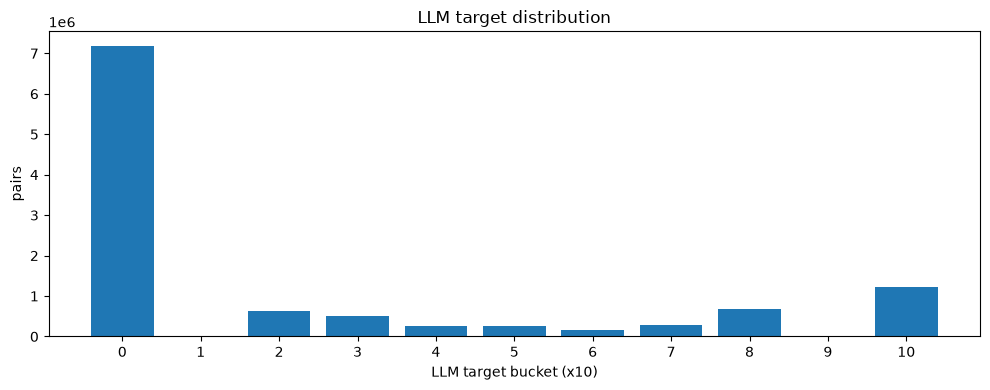

In [27]:
human_only_pairs = matches.join(matches_llm, on=["id1", "id2"], how="anti").select(pl.len()).collect().item()
print("human pairs missing in matches_llm:", human_only_pairs)

llm_total = matches_llm.select(pl.len()).collect().item()
uncertain = matches_llm.filter(pl.col("target").is_between(0.3, 0.7)).select(pl.len()).collect().item()
print(f"llm targets in uncertain zone 0.3-0.7: {uncertain} ({uncertain / llm_total:.4f})")

llm_duplicates = matches_llm.group_by("id1", "id2").len().filter(pl.col("len") > 1).select(pl.len()).collect().item()
print("duplicate pairs in matches_llm:", llm_duplicates)

llm_self_pairs = matches_llm.filter(pl.col("id1") == pl.col("id2")).select(pl.len()).collect().item()
print("self pairs in matches_llm:", llm_self_pairs)

llm_with_both_items = (
    matches_llm.join(item_categories.lazy(), left_on="id1", right_on="id")
    .join(item_categories.lazy(), left_on="id2", right_on="id")
    .select(pl.len())
    .collect()
    .item()
)
print(f"llm pairs with both items in items_human: {llm_with_both_items} ({llm_with_both_items / llm_total:.4f})")

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(llm_distribution["bucket"].to_list(), llm_distribution["len"].to_numpy(), width=0.8)
ax.set_xlabel("LLM target bucket (x10)")
ax.set_ylabel("pairs")
ax.set_xticks(range(11))
ax.set_title("LLM target distribution")
plt.tight_layout()
plt.show()

In [28]:
llm_pair_ids = matches_llm.select("id1", "id2").collect()
item_ids = items.select("id").collect()

found1 = llm_pair_ids.join(item_ids, left_on="id1", right_on="id").height
found2 = llm_pair_ids.join(item_ids, left_on="id2", right_on="id").height
found_both = llm_pair_ids.join(item_ids, left_on="id1", right_on="id").join(item_ids, left_on="id2", right_on="id").height
n = llm_pair_ids.height
print(f"llm pairs: {n}")
print(f"id1 in items: {found1} ({found1 / n:.4f}), id2 in items: {found2} ({found2 / n:.4f}), both: {found_both} ({found_both / n:.4f})")

llm pairs: 11187780
id1 in items: 11187780 (1.0000), id2 in items: 11187780 (1.0000), both: 11187780 (1.0000)


llm categories via items (vs items_human: 0 rows):
shape: (20, 2)
┌─────────────────────────┬────────┐
│ category                ┆ len    │
│ ---                     ┆ ---    │
│ str                     ┆ u32    │
╞═════════════════════════╪════════╡
│ Одежда                  ┆ 596224 │
│ Автотовары              ┆ 593803 │
│ Обувь                   ┆ 589894 │
│ Электроника             ┆ 584100 │
│ Дом и сад               ┆ 572845 │
│ …                       ┆ …      │
│ Хобби и творчество      ┆ 548332 │
│ Спорт и отдых           ┆ 547036 │
│ Ювелирные изделия       ┆ 523549 │
│ Бытовая химия           ┆ 517729 │
│ Музыкальные инструменты ┆ 515675 │
└─────────────────────────┴────────┘


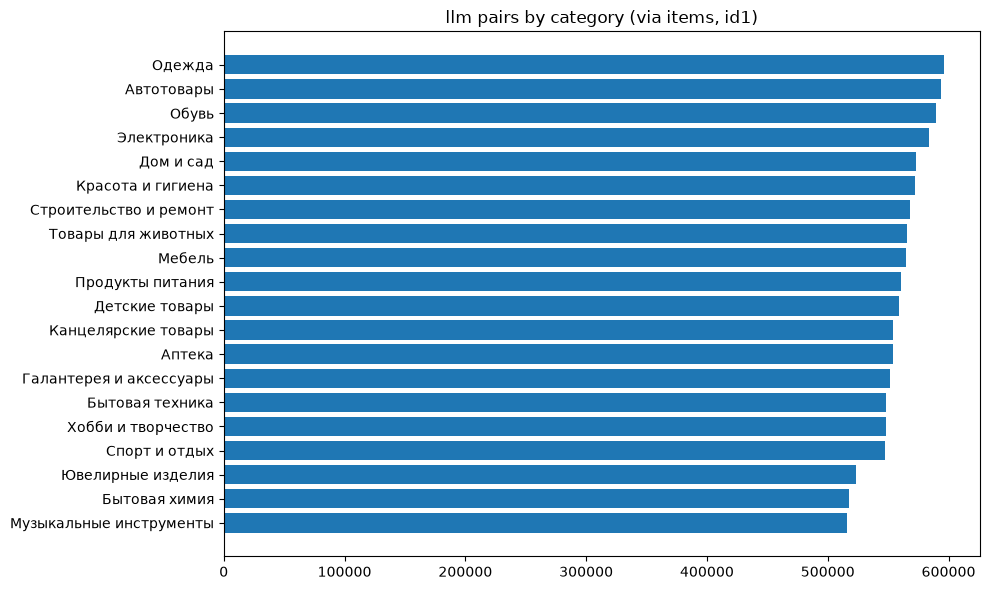

In [29]:
items_categories_full = items.select("id", "category").collect()

llm_categories = (
    matches_llm.join(items_categories_full.lazy(), left_on="id1", right_on="id")
    .group_by("category")
    .len()
    .sort("len", descending=True)
    .collect()
)
print("llm categories via items (vs items_human: 0 rows):")
print(llm_categories)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(llm_categories["category"].to_list(), llm_categories["len"].to_numpy())
ax.invert_yaxis()
ax.set_title("llm pairs by category (via items, id1)")
plt.tight_layout()
plt.show()

In [30]:
if overlap.height:
    human_pos = overlap.filter(pl.col("target_human") == 1)["target_llm"].to_numpy()
    human_neg = overlap.filter(pl.col("target_human") == 0)["target_llm"].to_numpy()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    axes[0].hist(human_neg, bins=20, alpha=0.6, label="human=0")
    axes[0].hist(human_pos, bins=20, alpha=0.6, label="human=1")
    axes[0].set_xlabel("LLM score")
    axes[0].set_ylabel("pairs")
    axes[0].legend()
    axes[0].set_title("LLM score distribution by human label")

    axes[1].boxplot([human_neg, human_pos], tick_labels=["human=0", "human=1"])
    axes[1].set_ylabel("LLM score")
    axes[1].set_title("LLM score by human label")
    plt.tight_layout()
    plt.show()
else:
    print("overlap is empty - plots skipped")

overlap is empty - plots skipped


In [31]:
if overlap.height:
    overlap_by_category = overlap.join(item_categories, left_on="id1", right_on="id")

    categories_list = overlap_by_category["category"].unique().to_list()
    for cat in categories_list:
        subset = overlap_by_category.filter(pl.col("category") == cat)
        pos_count = subset.filter(pl.col("target_human") == 1).height
        if pos_count < 2:
            continue
        corr = subset.select(pl.corr(pl.col("target_human"), pl.col("target_llm"))).item()
        ap = average_precision_score(subset["target_human"].to_numpy(), subset["target_llm"].to_numpy())
        print(f"{cat}: n={subset.height}, corr={corr:.4f}, ap={ap:.4f}")
else:
    print("overlap is empty - per-category agreement skipped")

overlap is empty - per-category agreement skipped


## 6. Атрибуты: items_human

Схема атрибутов переменная: разные наборы ключей у разных товаров (40499 наборов на 71130 айтемов сэмпла).


In [32]:
def parse_attributes(series: pl.Series) -> list[dict]:
    parsed = []
    for value in series:
        try:
            obj = json.loads(value)
            parsed.append(obj if isinstance(obj, dict) else {})
        except (TypeError, json.JSONDecodeError):
            parsed.append({})
    return parsed


attr_sample = (
    items_human.select("id", "attributes")
    .collect()
    .sample(fraction=0.1, seed=42)
)
parsed_attrs = parse_attributes(attr_sample["attributes"])

print("valid attribute jsons in sample:", sum(bool(a) for a in parsed_attrs), "of", len(parsed_attrs))

key_counter = Counter()
for attrs in parsed_attrs:
    key_counter.update(k for k, v in attrs.items() if v is not None)

print("attribute keys with non-null values (top 15):", key_counter.most_common(15))
print("avg non-null attributes per item:", round(sum(1 for a in parsed_attrs for v in a.values() if v is not None) / len(parsed_attrs), 2))

key_sets = {frozenset(a.keys()) for a in parsed_attrs if a}
print("distinct key sets in sample:", len(key_sets))

valid attribute jsons in sample: 71122 of 71130
attribute keys with non-null values (top 15): [('тип', 43715), ('бренд', 36701), ('страна-изготовитель', 28286), ('комплектация', 26717), ('цвет товара', 25593), ('валюта', 16545), ('страна производства', 15443), ('пол', 13327), ('материал', 12028), ('состав', 11253), ('цвет', 10384), ('вес товара, г', 10306), ('название цвета', 9992), ('гарантийный срок', 9734), ('артикул', 9534)]
avg non-null attributes per item: 12.62
distinct key sets in sample: 40499


In [33]:
filled_rows = [
    (item_id, key, value)
    for item_id, attrs in zip(attr_sample["id"], parsed_attrs)
    for key, value in attrs.items()
    if value is not None
]
attr_long = pl.DataFrame(filled_rows, schema=["id", "key", "value"], orient="row")
print("filled attribute cells in sample:", attr_long.height)

attr_coverage = (
    attr_long.group_by("key")
    .agg(pl.len().alias("n_filled"), pl.col("value").n_unique().alias("n_distinct"))
    .with_columns((pl.col("n_filled") / len(parsed_attrs)).round(4).alias("coverage"))
    .sort("n_filled", descending=True)
)
print("keys with coverage > 5%:", attr_coverage.filter(pl.col("coverage") > 0.05)["key"].to_list())
attr_coverage

filled attribute cells in sample: 897345
keys with coverage > 5%: ['тип', 'бренд', 'страна-изготовитель', 'комплектация', 'цвет товара', 'валюта', 'страна производства', 'пол', 'материал', 'состав', 'цвет', 'вес товара, г', 'название цвета', 'гарантийный срок', 'артикул', 'коллекция', 'длина упаковки', 'высота упаковки', 'ширина упаковки', 'упаковка', 'единиц в одном товаре', 'целевая аудитория', 'сезон', 'особенности', 'российский размер', 'назначение', 'модель', 'материал корпуса', 'бренд в одежде и обуви', 'срок годности', 'размеры, мм', 'ширина, см', 'вид выпуска товара']


key,n_filled,n_distinct,coverage
str,u32,u32,f64
"""тип""",43715,4993,0.6146
"""бренд""",36701,8143,0.516
"""страна-изготовитель""",28286,99,0.3977
"""комплектация""",26717,16738,0.3756
"""цвет товара""",25593,1348,0.3598
…,…,…,…
"""высота кресла, в сантиметрах""",1,1,0.0
"""общая глубина (см)""",1,1,0.0
"""длина гильзы""",1,1,0.0


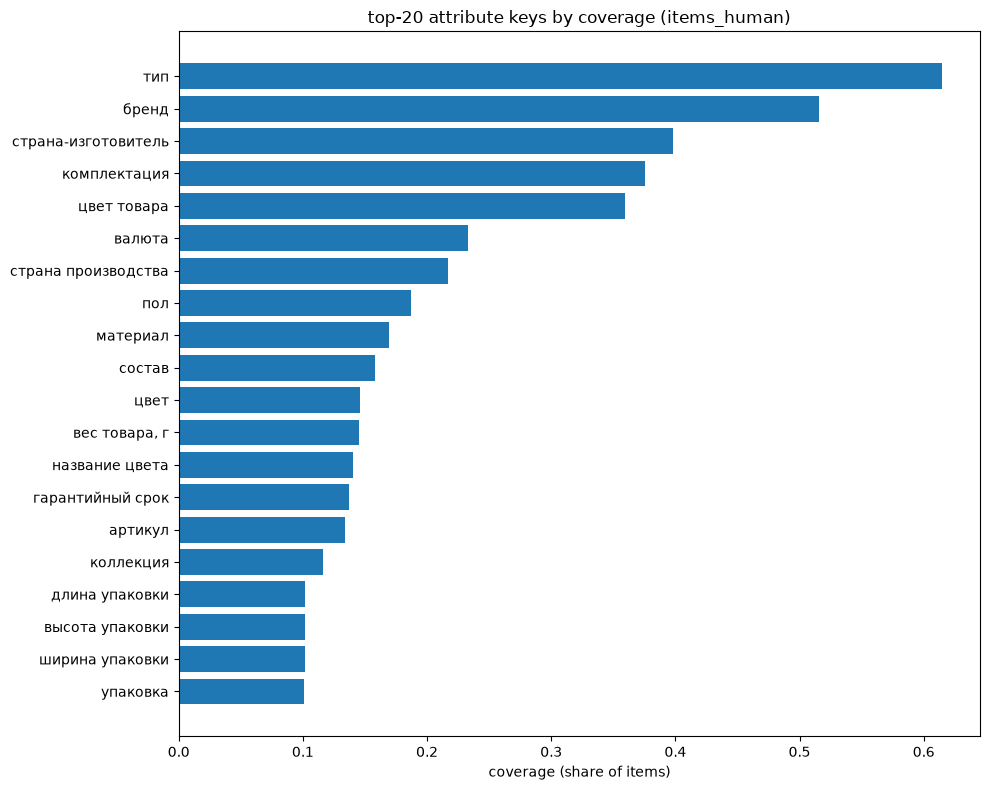

In [34]:
top20 = attr_coverage.head(20)
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top20["key"].to_list(), top20["coverage"].to_numpy())
ax.invert_yaxis()
ax.set_xlabel("coverage (share of items)")
ax.set_title("top-20 attribute keys by coverage (items_human)")
plt.tight_layout()
plt.show()

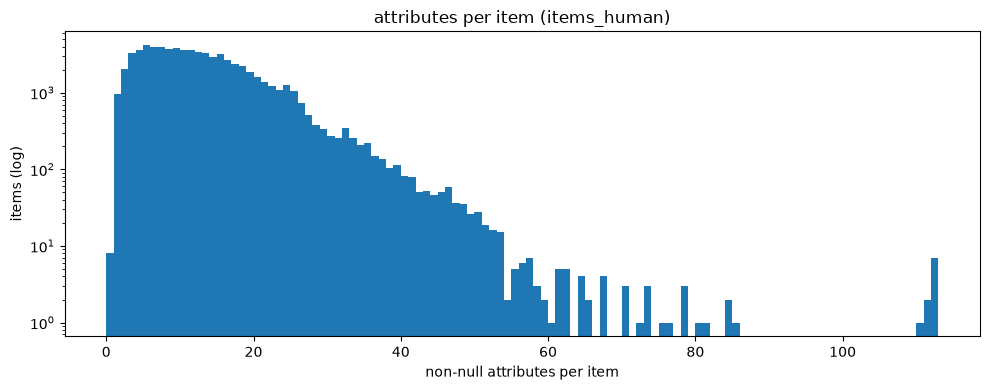

mean: 12.62 median: 11


In [35]:
n_attrs = [sum(1 for v in a.values() if v is not None) for a in parsed_attrs]
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(n_attrs, bins=range(0, max(n_attrs) + 2), log=True)
ax.set_xlabel("non-null attributes per item")
ax.set_ylabel("items (log)")
ax.set_title("attributes per item (items_human)")
plt.tight_layout()
plt.show()
print("mean:", round(np.mean(n_attrs), 2), "median:", int(np.median(n_attrs)))

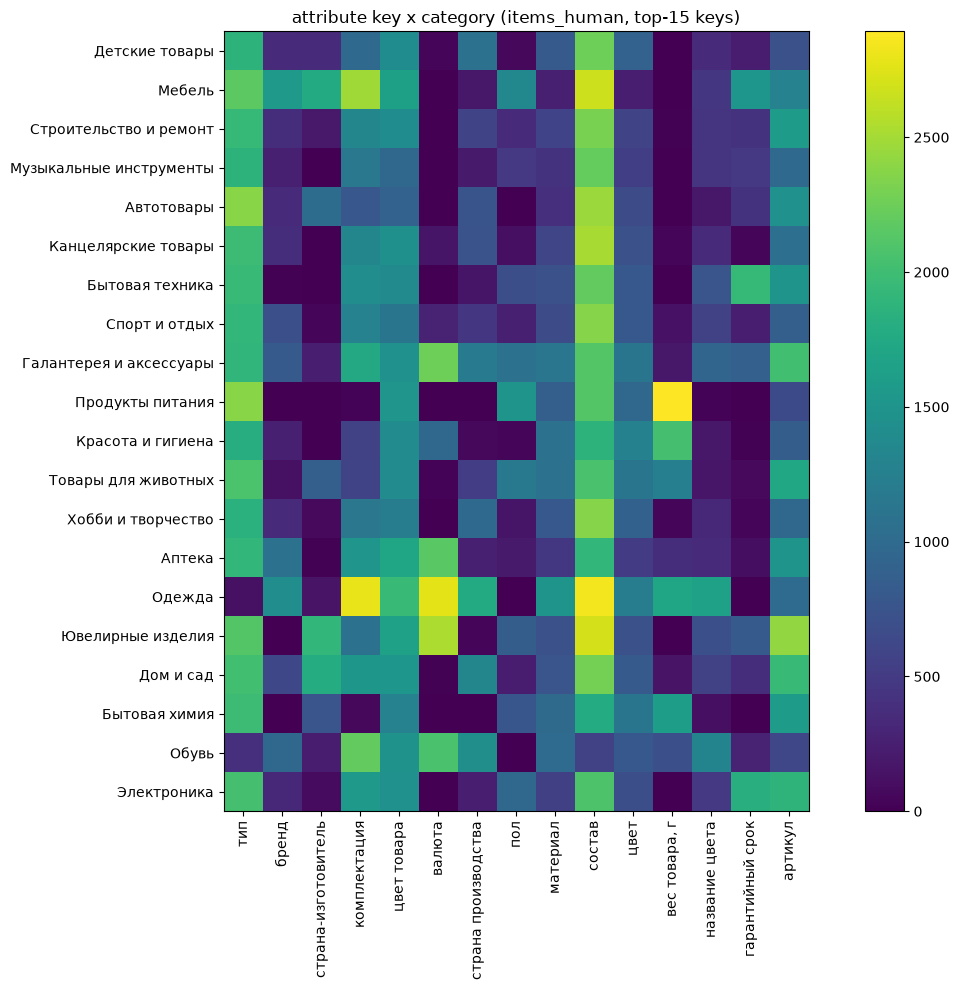

--- top values: тип ---
shape: (5, 2)
┌────────────────────────┬───────┐
│ value                  ┆ count │
│ ---                    ┆ ---   │
│ str                    ┆ u32   │
╞════════════════════════╪═══════╡
│ кольцо                 ┆ 1150  │
│ корм сухой             ┆ 671   │
│ аксессуар для струнных ┆ 579   │
│ очки для чтения        ┆ 546   │
│ очки для дали          ┆ 515   │
└────────────────────────┴───────┘
--- top values: бренд ---
shape: (5, 2)
┌──────────────┬───────┐
│ value        ┆ count │
│ ---          ┆ ---   │
│ str          ┆ u32   │
╞══════════════╪═══════╡
│ нет бренда   ┆ 5033  │
│ лига диванов ┆ 433   │
│ sokolov      ┆ 407   │
│ lisik.       ┆ 288   │
│ acuvue       ┆ 210   │
└──────────────┴───────┘
--- top values: страна-изготовитель ---
shape: (5, 2)
┌──────────┬───────┐
│ value    ┆ count │
│ ---      ┆ ---   │
│ str      ┆ u32   │
╞══════════╪═══════╡
│ россия   ┆ 12939 │
│ китай    ┆ 8989  │
│ италия   ┆ 659   │
│ германия ┆ 592   │
│ сша      ┆ 539   

In [36]:
category_keys = (
    attr_long.select("id", "key")
    .join(item_categories, on="id")
    .group_by("category", "key")
    .len()
)

top_keys = attr_coverage.head(15)["key"].to_list()
cat_matrix = (
    category_keys.filter(pl.col("key").is_in(top_keys))
    .pivot(on="key", index="category", values="len")
    .fill_null(0)
)
cats_order = cat_matrix["category"].to_list()
matrix_keys = cat_matrix.select(pl.exclude("category")).to_numpy()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(matrix_keys, cmap="viridis")
ax.set_xticks(range(len(top_keys)), top_keys, rotation=90)
ax.set_yticks(range(len(cats_order)), cats_order)
ax.set_title("attribute key x category (items_human, top-15 keys)")
plt.colorbar(im)
plt.tight_layout()
plt.show()

for key in attr_coverage.head(3)["key"].to_list():
    print(f"--- top values: {key} ---")
    print(attr_long.filter(pl.col("key") == key)["value"].value_counts().sort("count", descending=True).head(5))

## 7. Атрибуты: items (сэмпл 100K) vs items_human


valid attribute jsons in items sample: 297622 of 297761
items top-15: [('тип', 189929), ('бренд', 178930), ('комплектация', 172627), ('цвет товара', 138503), ('страна-изготовитель', 133778), ('проба', 95126), ('вес товара, г', 91068), ('вставка', 86729), ('гарантийный срок', 86666), ('состав ювелирного изделия', 70701), ('пол', 62652), ('целевая аудитория', 60581), ('вид выпуска товара', 58089), ('средний вес изделия, гр', 56257), ('цвет', 55536)]
items_human top-15: [('тип', 43715), ('бренд', 36701), ('страна-изготовитель', 28286), ('комплектация', 26717), ('цвет товара', 25593), ('валюта', 16545), ('страна производства', 15443), ('пол', 13327), ('материал', 12028), ('состав', 11253), ('цвет', 10384), ('вес товара, г', 10306), ('название цвета', 9992), ('гарантийный срок', 9734), ('артикул', 9534)]


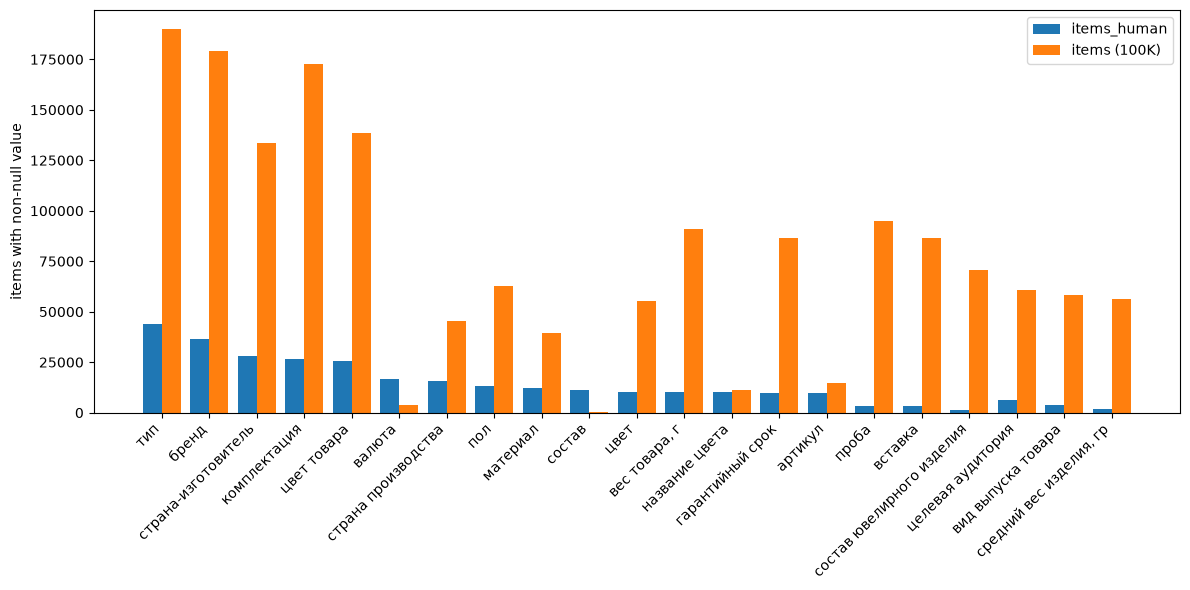

In [37]:
items_attr_sample = pl.concat([
    items.select("id", "attributes").slice(off, 100_000).collect()
    for off in (0, 6_650_000, 13_300_000)
])
parsed_items_attrs = parse_attributes(items_attr_sample["attributes"])
print("valid attribute jsons in items sample:", sum(bool(a) for a in parsed_items_attrs), "of", len(parsed_items_attrs))

items_key_counter = Counter()
for attrs in parsed_items_attrs:
    items_key_counter.update(k for k, v in attrs.items() if v is not None)

print("items top-15:", items_key_counter.most_common(15))
print("items_human top-15:", key_counter.most_common(15))

keys = list(dict.fromkeys([k for k, _ in key_counter.most_common(15)] + [k for k, _ in items_key_counter.most_common(15)]))
human_counts = [key_counter[k] for k in keys]
items_counts = [items_key_counter[k] for k in keys]

x = np.arange(len(keys))
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - 0.2, human_counts, width=0.4, label="items_human")
ax.bar(x + 0.2, items_counts, width=0.4, label="items (100K)")
ax.set_xticks(x, keys, rotation=45, ha="right")
ax.set_ylabel("items with non-null value")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Сигналы для модели


In [38]:
item_fields = items_human.select("id", "name", "category")

pairs_with_items = (
    matches.rename({"target": "target_human"})
    .join(item_fields, left_on="id1", right_on="id")
    .rename({"name": "name1", "category": "cat1"})
    .join(item_fields, left_on="id2", right_on="id")
    .rename({"name": "name2", "category": "cat2"})
    .select(
        "target_human",
        "cat1",
        "cat2",
        "name1",
        "name2",
        pl.col("name1").str.len_chars().alias("len1"),
        pl.col("name2").str.len_chars().alias("len2"),
        pl.col("name1").str.to_lowercase().str.split(" ").alias("tokens1"),
        pl.col("name2").str.to_lowercase().str.split(" ").alias("tokens2"),
    )
    .collect()
)

print("pairs with both names available:", pairs_with_items.height)

pairs with both names available: 365654


In [39]:
feature_scores = pairs_with_items.select(
    (pl.col("name1") == pl.col("name2")).alias("exact_name"),
    (pl.col("cat1") == pl.col("cat2")).alias("same_category"),
    (pl.col("tokens1").list.set_intersection("tokens2").list.len() / pl.col("tokens1").list.set_union("tokens2").list.len()).alias("name_jaccard"),
    (pl.min_horizontal("len1", "len2") / pl.max_horizontal("len1", "len2")).alias("name_len_ratio"),
    "cat1",
    "target_human",
)

y = feature_scores["target_human"].to_numpy()
feature_names = ["exact_name", "same_category", "name_jaccard", "name_len_ratio"]
mean_pr_auc = 0
for feature in feature_names:
    scores = feature_scores[feature].cast(pl.Float64).fill_null(0.0).to_numpy()
    pr_auc = average_precision_score(y, scores)
    mean_pr_auc += pr_auc
    print(f"{feature}: PR-AUC = {pr_auc:.4f}")

categories = feature_scores["cat1"].unique().to_list()
macro_pr_aucs = []
for feature in feature_names:
    per_category = []
    for cat in categories:
        cat_subset = feature_scores.filter(pl.col("cat1") == cat)
        pos_count = cat_subset.filter(pl.col("target_human") == 1).height
        if pos_count < 2:
            continue
        per_category.append(
            average_precision_score(
                cat_subset["target_human"].to_numpy(),
                cat_subset[feature].cast(pl.Float64).fill_null(0.0).to_numpy(),
            )
        )
    macro_pr_auc = sum(per_category) / len(per_category)
    macro_pr_aucs.append(macro_pr_auc)
    print(f"{feature}: Macro PR-AUC ({len(per_category)} categories) = {macro_pr_auc:.4f}")

print(f"mean PR-AUC = {mean_pr_auc / len(feature_names):.4f}")
print(f"mean Macro PR-AUC (categories) = {sum(macro_pr_aucs) / len(macro_pr_aucs):.4f}")

exact_name: PR-AUC = 0.2578
same_category: PR-AUC = 0.2568
name_jaccard: PR-AUC = 0.3020
name_len_ratio: PR-AUC = 0.2510
exact_name: Macro PR-AUC (20 categories) = 0.2668
same_category: Macro PR-AUC (20 categories) = 0.2611
name_jaccard: Macro PR-AUC (20 categories) = 0.3193
name_len_ratio: Macro PR-AUC (20 categories) = 0.2540
mean PR-AUC = 0.2669
mean Macro PR-AUC (categories) = 0.2753


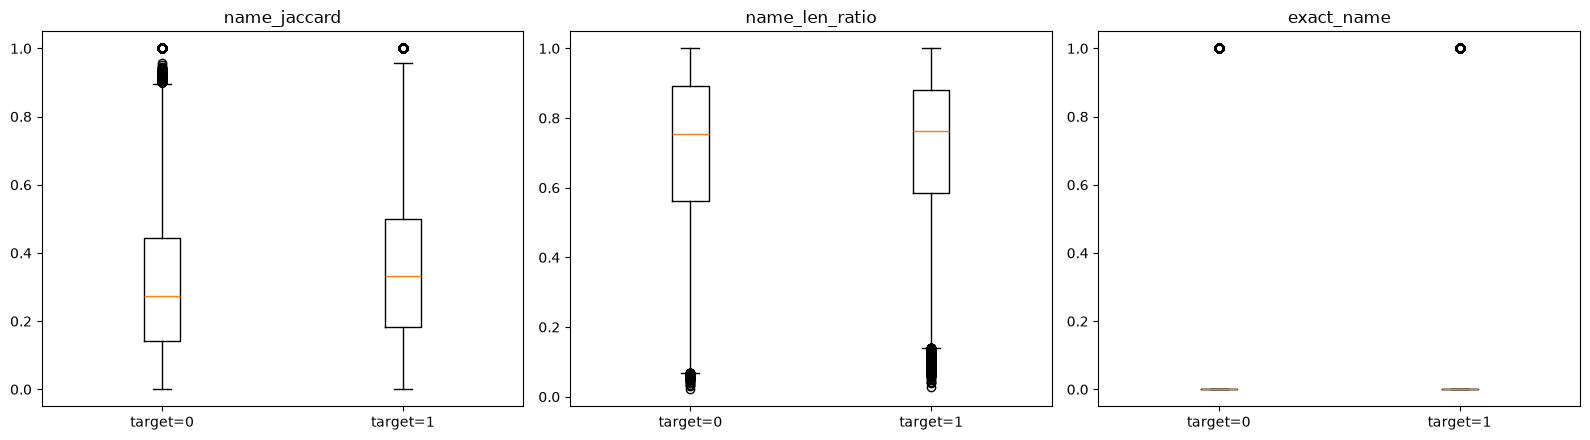

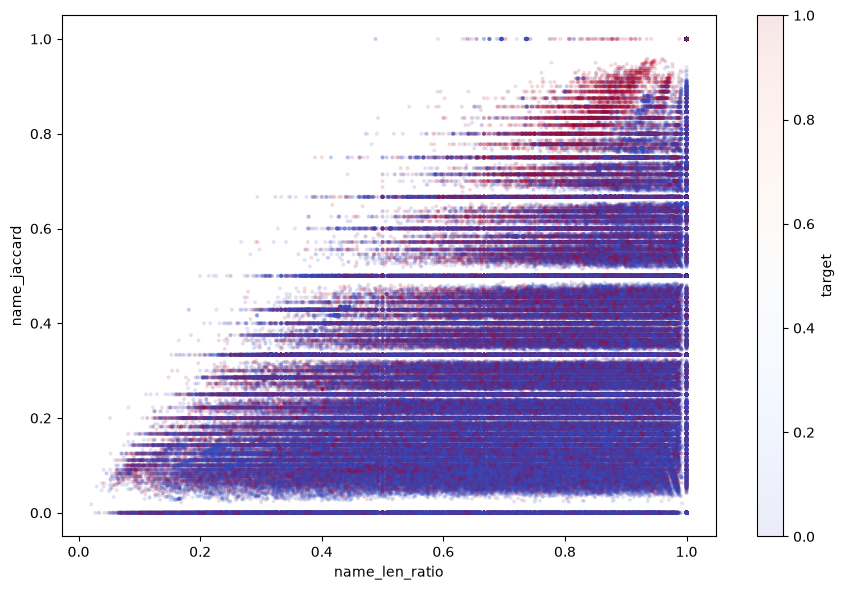

In [40]:
pos = feature_scores.filter(pl.col("target_human") == 1)
neg = feature_scores.filter(pl.col("target_human") == 0)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, feature in zip(axes, ["name_jaccard", "name_len_ratio", "exact_name"]):
    ax.boxplot(
        [neg[feature].cast(pl.Float64).to_numpy(), pos[feature].cast(pl.Float64).to_numpy()],
        tick_labels=["target=0", "target=1"],
    )
    ax.set_title(feature)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(
    feature_scores["name_len_ratio"].cast(pl.Float64).fill_null(0.0).to_numpy(),
    feature_scores["name_jaccard"].cast(pl.Float64).fill_null(0.0).to_numpy(),
    c=feature_scores["target_human"].to_numpy(),
    cmap="coolwarm", alpha=0.1, s=4,
)
ax.set_xlabel("name_len_ratio")
ax.set_ylabel("name_jaccard")
plt.colorbar(sc, label="target")
plt.tight_layout()
plt.show()

In [41]:
pair_ids = matches.select(pl.col("id1").alias("id")).collect()
pair_ids = pair_ids.vstack(matches.select(pl.col("id2").alias("id")).collect()).unique()

attr_rows = (
    items_human.filter(pl.col("id").is_in(pair_ids["id"]))
    .select("id", "attributes")
    .collect()
)
attrs_map = {}
for row in attr_rows.iter_rows():
    try:
        attrs_map[row[0]] = json.loads(row[1])
    except (TypeError, json.JSONDecodeError):
        attrs_map[row[0]] = {}

def attr_value(item_id, key):
    value = attrs_map.get(item_id, {}).get(key, None)
    return value if isinstance(value, str) and value.strip() else None

pair_attrs = matches.rename({"target": "target_human"}).select("id1", "id2", "target_human").collect()
pair_attrs = pair_attrs.with_columns(
    pl.col("id1").map_elements(lambda x: attr_value(x, "бренд"), return_dtype=pl.String).alias("brand1"),
    pl.col("id2").map_elements(lambda x: attr_value(x, "бренд"), return_dtype=pl.String).alias("brand2"),
    pl.col("id1").map_elements(lambda x: attr_value(x, "страна-изготовитель"), return_dtype=pl.String).alias("country1"),
    pl.col("id2").map_elements(lambda x: attr_value(x, "страна-изготовитель"), return_dtype=pl.String).alias("country2"),
    pl.col("id1").map_elements(lambda x: attr_value(x, "тип"), return_dtype=pl.String).alias("type1"),
    pl.col("id2").map_elements(lambda x: attr_value(x, "тип"), return_dtype=pl.String).alias("type2"),
)

attr_features = pair_attrs.with_columns(
    ((pl.col("brand1").is_not_null() & (pl.col("brand1") == pl.col("brand2"))).fill_null(False)).alias("brand_match"),
    ((pl.col("country1").is_not_null() & (pl.col("country1") == pl.col("country2"))).fill_null(False)).alias("country_match"),
    ((pl.col("type1").is_not_null() & (pl.col("type1") == pl.col("type2"))).fill_null(False)).alias("type_match"),
)

print("pairs with attr on both sides - brand:", attr_features.filter(pl.col("brand1").is_not_null() & pl.col("brand2").is_not_null()).height,
      ", country:", attr_features.filter(pl.col("country1").is_not_null() & pl.col("country2").is_not_null()).height)

y_attr = attr_features["target_human"].to_numpy()
for feature in ["brand_match", "country_match", "type_match"]:
    scores = attr_features[feature].cast(pl.Float64).to_numpy()
    print(f"{feature}: PR-AUC = {average_precision_score(y_attr, scores):.4f}")

C:\Users\Alexander\AppData\Local\Temp\ipykernel_6352\286679198.py:7: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  .collect()


pairs with attr on both sides - brand: 47695 , country: 2
brand_match: PR-AUC = 0.2562
country_match: PR-AUC = 0.2568
type_match: PR-AUC = 0.2560


## 9. Сводка выводов


In [42]:
print("summary")
print(f"categories in items_human: {category_counts.height}, in items: {items_cat_counts.height}")
print(f"matches: {match_stats['n_pairs'].item()}, positive rate: {match_stats['positive_rate'].item()}")
print(f"cross-category pairs: {pair_categories.filter(pl.col('cat1') != pl.col('cat2')).height}")
print(f"missing id2 in items_human: {missing_id2}, missing id1: {missing_id1}")
print(f"llm pairs: {llm_stats['n_pairs'].item()}, mean target: {llm_stats['mean_target'].item()}, median: {llm_stats['median_target'].item()}")
print(f"human-llm overlapping pairs: {overlap.height}, shared items: {shared_items}")
print(f"llm pairs with both items in items: {found_both} ({found_both / n:.4f})")
print("items quality:", items_quality.to_dicts()[0])

summary
categories in items_human: 20, in items: 20
matches: 365654, positive rate: 0.2568
cross-category pairs: 0
missing id2 in items_human: 0, missing id1: 0
llm pairs: 11187780, mean target: 0.2436, median: 0.0
human-llm overlapping pairs: 0, shared items: 0
llm pairs with both items in items: 11187780 (1.0000)
items quality: {'null_names': 0, 'empty_names': 11, 'null_attrs': 0, 'empty_attrs': 0, 'null_category': 0, 'n_categories': 20}


## 10. Выводы анализа данных

### Объёмы и качество

| Файл | Строк | Комментарий |
|---|---|---|
| `items` | 13 397 761 | 20 категорий; 11 пустых имён; **8 761 656 уникальных имён** (≈4.6M дублей названий у разных товаров); attributes без null/пустых и 0 битых JSON; 0 дублей id |
| `items_human` | 711 304 | 20 категорий, идеальная чистота (0 null/пустых, 0 битых JSON) |
| `matches` | 365 654 | positive rate **25.7%**; 0 кросс-категорийных пар; пары уникальны; без self-pairs; max 13 пар на товар |
| `matches_llm` | 11 187 780 | mean target 0.244, median 0; таргеты: **64.2% = 0**, 12.4% (0; 0.5), 12.5% [0.5; 1), 10.9% = 1; 10.6% в зоне 0.3–0.7; max 122 пары на товар; равномерно по 20 категориям |

### Ключевой факт: пулы товаров не пересекаются

- Общих `id` между товарами из human-пар и товарами из llm-пар: **0**.
- Общих пар (id1, id2) между `matches` и `matches_llm`: **0**.
- Все llm-пары (100%) имеют оба товара в `items`; все human-пары (100%) — в `items_human`.

Следствие: согласованность LLM- и human-разметки проверить напрямую нельзя. Тестовые товары тоже другие — **модель обязана генерализовать по тексту и атрибутам, без памяти по id/парам**.

### Атрибуты

- 17 200 различных ключей, в среднем **12.6 непустых атрибута** на товар.
- Топ-ключи: тип (61%), бренд (52%), страна-изготовитель (40%), комплектация (38%), цвет товара (36%); 33 ключа с покрытием >5%.
- В `items` топ смещён в сторону ювелирки (проба, вставка, состав ювелирного изделия) — распределение ключей отличается от `items_human`. **Не опираться на фиксированный набор ключей.**
- Спец-значения: «нет бренда» (5033 шт. в выборке 71K) — при сравнении брендов трактовать как отсутствие.

### Признаки против human-таргета (baseline = positive rate 0.257)

| Признак | PR-AUC | Macro PR-AUC |
|---|---|---|
| exact_name | 0.258 | 0.267 |
| same_category | 0.257 | 0.261 |
| **name_jaccard** | **0.302** | **0.319** |
| name_len_ratio | 0.251 | 0.254 |

- Среднее по простым фичам: **0.267 / 0.275 (macro)** — все в пределах noise-множителя от baseline.
- Атрибутные совпадения (brand/country/type_match): 0.256–0.257 — тоже на baseline, покрытие мизерное (бренд с двух сторон — 47.7K пар, страна — 2 пары).

**Вывод: лексическая похожесть имён и совпадения атрибутов сами по себе не разделяют классы.**

### Следствия для модели

1. Основное решение — **семантический cross-encoder** на тексте `name + attributes + category` (BCE, soft-таргеты 0..1 из LLM-разметки).
2. Категория не разделяет пары (0 кросс-категорийных), но полезна как контекст в тексте товара и критична для macro-метрики по 20 категориям.
3. Тренировка на `matches_llm` (11.2M пар); `matches` + `items_human` — только для эмуляции пайплайна/валидации формата, переносимость скоров на другой пул не гарантирована.
4. Дубли имён у разных товаров и общий шум (11 пустых имён, 0.05% битых JSON) — модель должна быть устойчива к грязному тексту; не меморизировать названия.